# Análisis de datos y machine learning
El dataset seleccionado es de monitorización de pacientes en UCIs

## 1. Instalación librerías necesarias

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn ipykernel

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## 2. Importación librerías, carga de datos y exploración inicial

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. CARGA DE DATOS
df = pd.read_csv('ICU_Patient_Monitoring_Mortality_Prediction_15000.csv')
df

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PAT014996,27,Female,Elective,0.02,100.21,15.97,105.34,79.25,123.65,...,217.13,3.22,1034.24,1,0,13.41,13.89,8.30,0,0
14996,PAT014997,68,Male,Emergency,8.39,88.72,13.34,100.69,77.45,148.53,...,171.81,5.17,989.13,0,1,14.36,38.71,1.03,0,0
14997,PAT014998,24,Female,Elective,9.06,83.32,23.45,109.28,56.80,133.29,...,201.38,2.23,3007.17,0,1,18.94,19.35,12.90,1,0
14998,PAT014999,82,Female,Emergency,3.60,86.64,23.59,95.87,67.42,137.37,...,203.62,2.99,1402.62,0,1,17.93,38.89,12.27,0,0


## 3. Limpieza y transformación de datos

In [11]:
# 1. Eliminación de columnas no predictivas
df_clean = df.drop(columns=['patient_id'])

# 2. Manejo de valores nulos (si existieran en este dataset sintético)
df_clean = df_clean.dropna()

# 3. Encoding de variables categóricas (Género y Tipo de Admisión)
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender']) # Male/Female -> 0/1
df_clean = pd.get_dummies(df_clean, columns=['admission_type'], drop_first=True)

display(df_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       15000 non-null  int64  
 1   gender                    15000 non-null  int64  
 2   comorbidity_score         15000 non-null  float64
 3   heart_rate_mean           15000 non-null  float64
 4   heart_rate_std            15000 non-null  float64
 5   heart_rate_max            15000 non-null  float64
 6   heart_rate_min            15000 non-null  float64
 7   systolic_bp_mean          15000 non-null  float64
 8   systolic_bp_std           15000 non-null  float64
 9   respiratory_rate_mean     15000 non-null  float64
 10  spo2_mean                 15000 non-null  float64
 11  temperature_mean          15000 non-null  float64
 12  glucose_mean              15000 non-null  float64
 13  lactate_mean              15000 non-null  float64
 14  urine_output_tota

None

## 4. Análisis Exploratorio de Datos (EDA)

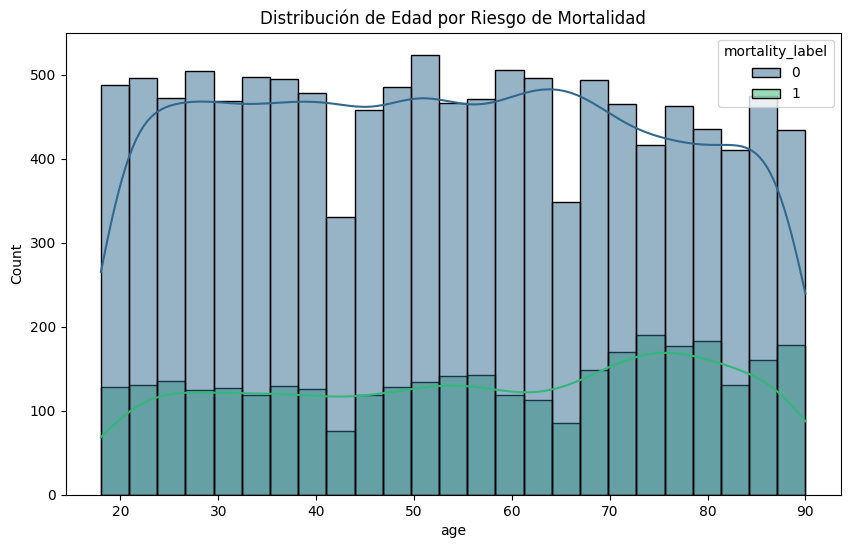

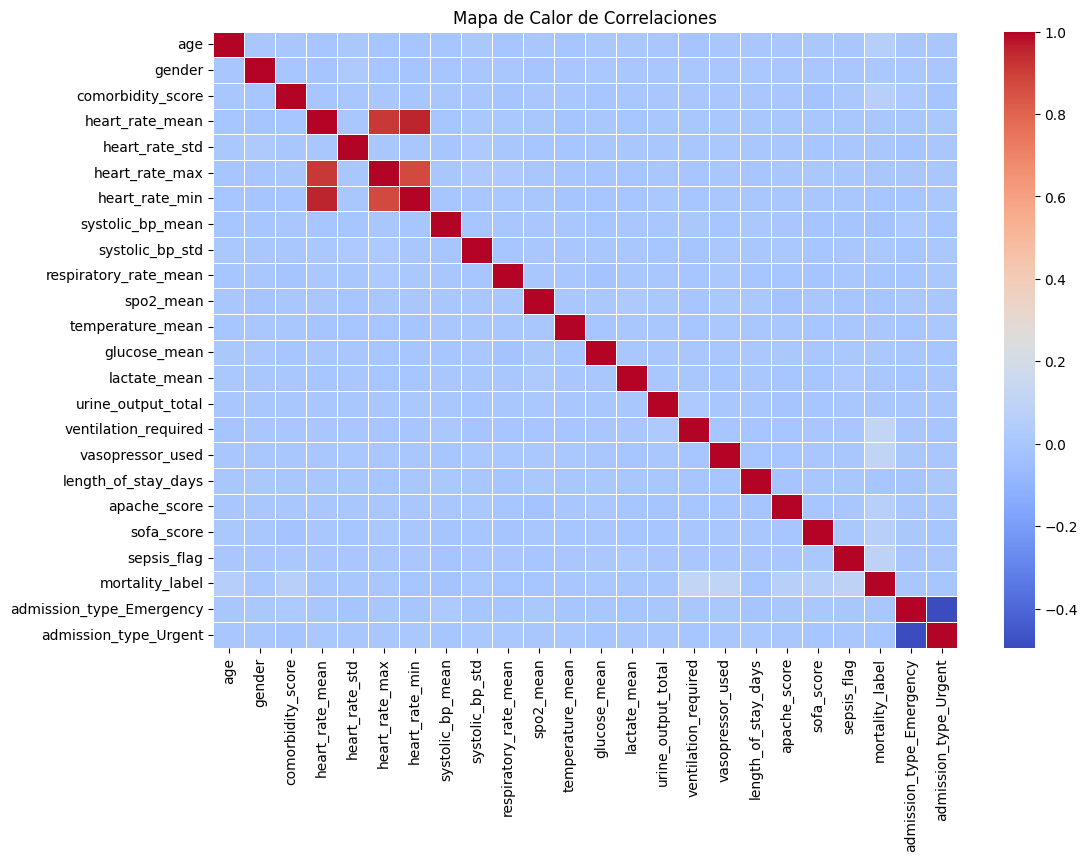

In [12]:
# Visualización 1: Distribución de Edad vs Mortalidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='age', hue='mortality_label', kde=True, palette='viridis')
plt.title('Distribución de Edad por Riesgo de Mortalidad')
plt.show()

# Visualización 2: Correlación de variables críticas
plt.figure(figsize=(12, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

### Traducción indicadores para mejor entendimiento

In [13]:
# Diccionario de mapeo: 'Nombre_Original': 'Nombre_Español'
traducciones = {
    'age': 'Edad',
    'gender': 'Género',
    'comorbidity_score': 'Puntaje_Comorbilidad',
    'heart_rate_mean': 'Frecuencia_Cardíaca_Media',
    'heart_rate_std': 'Frecuencia_Cardíaca_Desv',
    'heart_rate_max': 'Frecuencia_Cardíaca_Máx',
    'heart_rate_min': 'Frecuencia_Cardíaca_Mín',
    'systolic_bp_mean': 'Presión_Sistólica_Media',
    'systolic_bp_std': 'Presión_Sistólica_Desv',
    'systolic_bp_max': 'Presión_Sistólica_Máx',
    'systolic_bp_min': 'Presión_Sistólica_Mín',
    'diastolic_bp_mean': 'Presión_Diastólica_Media',
    'diastolic_bp_std': 'Presión_Diastólica_Desv',
    'diastolic_bp_max': 'Presión_Diastólica_Máx',
    'diastolic_bp_min': 'Presión_Diastólica_Mín',
    'respiratory_rate_mean': 'Frec. Respiratoria_Media',
    'spo2_mean': 'Saturación_Oxígeno_Media',
    'temperature_mean': 'Temperatura_Media',
    'gcs_min': 'Escala_Glasgow_Mín',
    'sofa_score': 'Puntaje_SOFA',
    'lactate_max': 'Lactato_Máx',
    'creatinine_max': 'Creatinina_Máx',
    'admission_type_Emergency': 'Admisión_Emergencia',
    'admission_type_Urgent': 'Admisión_Urgente',
    'glucose_mean': 'Glucosa_Media',
    'apache_score': 'Puntaje_APACHE_II',
    'urine_output_total': 'Gasto_Urinario_Total',
    'respiratory_rate_std': 'Frec_Respiratoria_Desv',
    'spo2_std': 'Saturación_Oxígeno_Desv',
    'temp_std': 'Temperatura_Desv'
}

# Aplicar el renombramiento
df_clean = df_clean.rename(columns=traducciones)

print("Indicadores traducidos al español para los reportes finales.")
print(df_clean.columns.tolist())

Indicadores traducidos al español para los reportes finales.
['Edad', 'Género', 'Puntaje_Comorbilidad', 'Frecuencia_Cardíaca_Media', 'Frecuencia_Cardíaca_Desv', 'Frecuencia_Cardíaca_Máx', 'Frecuencia_Cardíaca_Mín', 'Presión_Sistólica_Media', 'Presión_Sistólica_Desv', 'Frec. Respiratoria_Media', 'Saturación_Oxígeno_Media', 'Temperatura_Media', 'Glucosa_Media', 'lactate_mean', 'Gasto_Urinario_Total', 'ventilation_required', 'vasopressor_used', 'length_of_stay_days', 'Puntaje_APACHE_II', 'Puntaje_SOFA', 'sepsis_flag', 'mortality_label', 'Admisión_Emergencia', 'Admisión_Urgente']


## 5. Entrenamiento del Modelo de Machine Learning

In [14]:
# Definición de variables
X = df_clean.drop('mortality_label', axis=1)
y = df_clean['mortality_label']

# División 80% entrenamiento - 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado de datos (importante para signos vitales con rangos distintos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicialización y entrenamiento del modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 6. Evaluación de resultados

Precisión Final: 76.40%

Reporte detallado:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      2297
           1       0.22      0.00      0.01       703

    accuracy                           0.76      3000
   macro avg       0.49      0.50      0.44      3000
weighted avg       0.64      0.76      0.66      3000



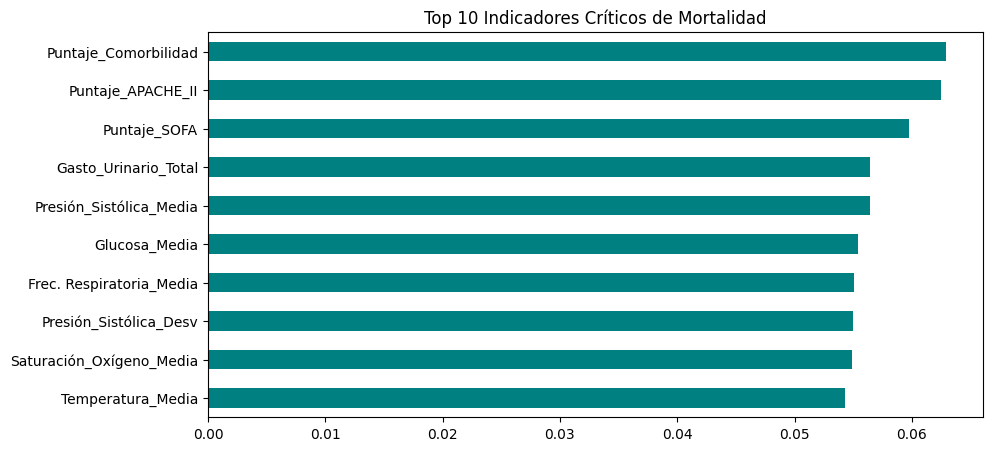

In [15]:
# Predicciones
y_pred = model.predict(X_test_scaled)

print(f"Precisión Final: {accuracy_score(y_test, y_pred):.2%}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred))

# Importancia de las variables (Insights de Negocio/Salud)
importancias = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importancias.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Indicadores Críticos de Mortalidad')
plt.gca().invert_yaxis()
plt.show()

### Resultados por género

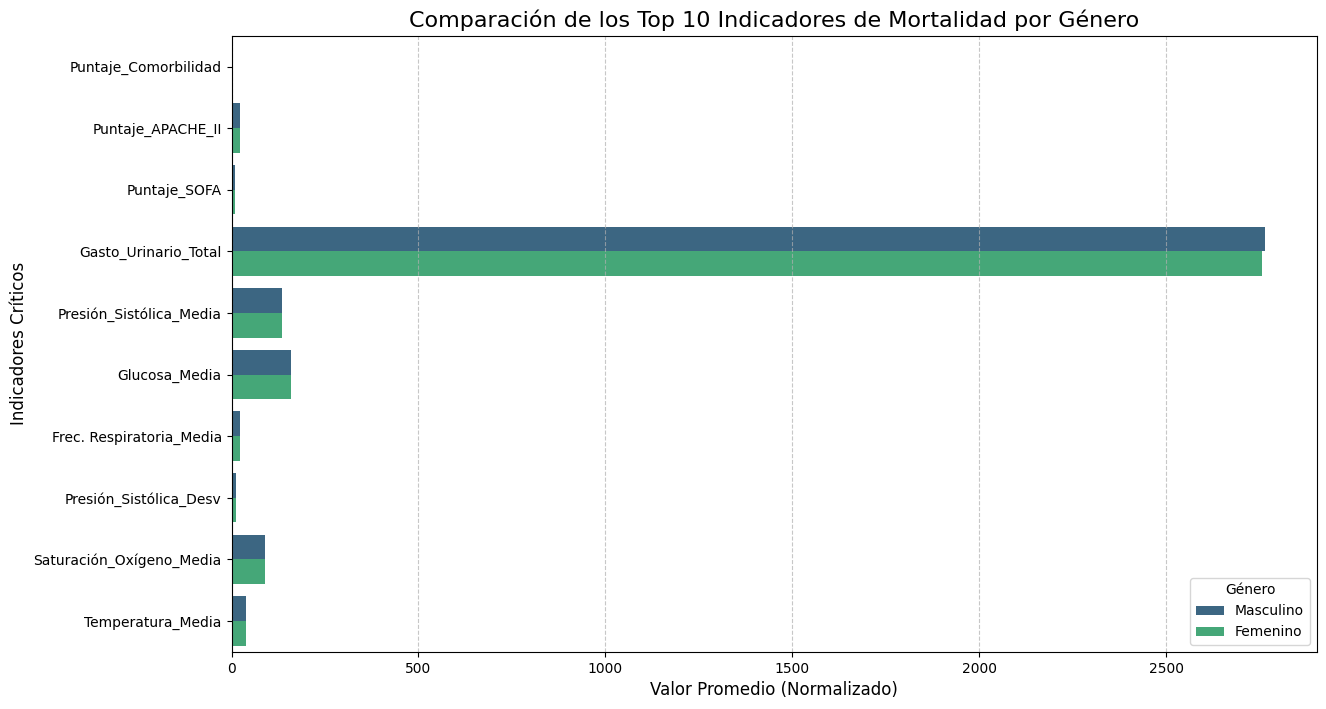

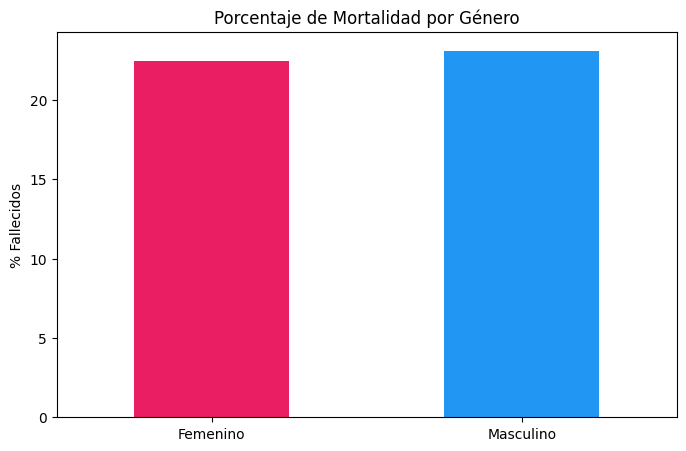

In [16]:
# 1. Identificar los nombres de las 10 variables más importantes
top_10_nombres = importancias.head(10).index.tolist()

# 2. Preparar los datos para el gráfico
# Creamos un sub-dataset con los top 10 indicadores + el Género
df_top10 = df_clean[top_10_nombres + ['Género']].copy()

# Mapeamos el Género a etiquetas legibles (si aún es 0 y 1)
# Asumiendo 0 = Femenino, 1 = Masculino (ajustar según tu LabelEncoder)
df_top10['Género_Etiqueta'] = df_top10['Género'].map({0: 'Femenino', 1: 'Masculino'})

# Transformamos el DataFrame a formato "largo" para Seaborn
df_melted = df_top10.melt(id_vars=['Género_Etiqueta'], 
                          value_vars=top_10_nombres, 
                          var_name='Indicador', 
                          value_name='Valor_Promedio')

# 3. Crear el gráfico comparativo
plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Valor_Promedio', y='Indicador', hue='Género_Etiqueta', 
            palette='viridis', errorbar=None)

plt.title('Comparación de los Top 10 Indicadores de Mortalidad por Género', fontsize=16)
plt.xlabel('Valor Promedio (Normalizado)', fontsize=12)
plt.ylabel('Indicadores Críticos', fontsize=12)
plt.legend(title='Género', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Visualización Extra: ¿Cuál es la tasa de mortalidad por género?
plt.figure(figsize=(8, 5))
tasa_mortalidad = df_clean.groupby('Género')['mortality_label'].mean() * 100
tasa_mortalidad.index = ['Femenino', 'Masculino']
tasa_mortalidad.plot(kind='bar', color=['#e91e63', '#2196f3'])
plt.title('Porcentaje de Mortalidad por Género')
plt.ylabel('% Fallecidos')
plt.xticks(rotation=0)
plt.show()